<a href="https://colab.research.google.com/github/ChonlasakThamana/ChonlasakThamana/blob/main/Classifier_SMS_spam_or_ham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import os


In [4]:
df = pd.read_csv("/content/spam.csv",encoding='latin-1')

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


Data Cleaning

In [6]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True, errors='ignore')

In [7]:
df.sample(5)

,v1,v2
3490,ham,Ok.
289,ham,"Dear,shall mail tonite.busy in the street,shal..."
2877,spam,Hey Boys. Want hot XXX pics sent direct 2 ur p...
3859,ham,Yep. I do like the pink furniture tho.
4730,ham,K:)eng rocking in ashes:)


In [8]:
df.rename(columns={'v1':'lable','v2':'text'},inplace=True)
df.sample(5)

,lable,text
1777,spam,Buy Space Invaders 4 a chance 2 win orig Arcad...
5158,ham,I will come with karnan car. Please wait till ...
828,ham,"Sorry light turned green, I meant another frie..."
3869,ham,Oh ok wait 4 me there... My lect havent finish
2916,ham,Yes. that will be fine. Love you. Be safe.


In [9]:
df['lable'] = df['lable'].astype(str).str.strip().map({'ham': 0, 'spam': 1})
df.head()

,lable,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
df.isnull().sum()

,0
lable,0
text,0


In [11]:
df.duplicated().sum()

np.int64(403)

In [12]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [13]:
df.head()

,lable,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


EDA

In [14]:
!pip install nltk

In [15]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [16]:
df['tokenized_text'] = df['text'].apply(nltk.word_tokenize)
df["num_words"] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()

,lable,text,tokenized_text,num_words
0,0,"Go until jurong point, crazy.. Available only ...","[Go, until, jurong, point, ,, crazy, .., Avail...",24
1,0,Ok lar... Joking wif u oni...,"[Ok, lar, ..., Joking, wif, u, oni, ...]",8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...",37
3,0,U dun say so early hor... U c already then say...,"[U, dun, say, so, early, hor, ..., U, c, alrea...",13
4,0,"Nah I don't think he goes to usf, he lives aro...","[Nah, I, do, n't, think, he, goes, to, usf, ,,...",15


In [17]:
df['tokenized_sentences'] = df['text'].apply(nltk.sent_tokenize)
df["num_sentences"] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,lable,text,tokenized_text,num_words,tokenized_sentences,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...","[Go, until, jurong, point, ,, crazy, .., Avail...",24,"[Go until jurong point, crazy.., Available onl...",2
1,0,Ok lar... Joking wif u oni...,"[Ok, lar, ..., Joking, wif, u, oni, ...]",8,"[Ok lar..., Joking wif u oni...]",2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...",37,[Free entry in 2 a wkly comp to win FA Cup fin...,2
3,0,U dun say so early hor... U c already then say...,"[U, dun, say, so, early, hor, ..., U, c, alrea...",13,[U dun say so early hor... U c already then sa...,1
4,0,"Nah I don't think he goes to usf, he lives aro...","[Nah, I, do, n't, think, he, goes, to, usf, ,,...",15,"[Nah I don't think he goes to usf, he lives ar...",1


In [19]:
df['num_characters'] = df['text'].apply(len)
df[df['lable']==0][["num_characters","num_words","num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [20]:
df['num_characters'] = df['text'].apply(len)
df[df['lable']==1][["num_characters","num_words","num_sentences"]].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


Data Preprocessing

In [21]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords.words("english")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [22]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [23]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

def stem(text):
    y = []
    for i in text:
        y.append(ps.stem(i))
    return " ".join(y)

df['stemmed_text'] = df['tokenized_text'].apply(stem)
df.head()

,lable,text,tokenized_text,num_words,tokenized_sentences,num_sentences,num_characters,stemmed_text
0,0,"Go until jurong point, crazy.. Available only ...","[Go, until, jurong, point, ,, crazy, .., Avail...",24,"[Go until jurong point, crazy.., Available onl...",2,111,"go until jurong point , crazi .. avail onli in..."
1,0,Ok lar... Joking wif u oni...,"[Ok, lar, ..., Joking, wif, u, oni, ...]",8,"[Ok lar..., Joking wif u oni...]",2,29,ok lar ... joke wif u oni ...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...",37,[Free entry in 2 a wkly comp to win FA Cup fin...,2,155,free entri in 2 a wkli comp to win fa cup fina...
3,0,U dun say so early hor... U c already then say...,"[U, dun, say, so, early, hor, ..., U, c, alrea...",13,[U dun say so early hor... U c already then sa...,1,49,u dun say so earli hor ... u c alreadi then sa...
4,0,"Nah I don't think he goes to usf, he lives aro...","[Nah, I, do, n't, think, he, goes, to, usf, ,,...",15,"[Nah I don't think he goes to usf, he lives ar...",1,61,"nah i do n't think he goe to usf , he live aro..."


In [24]:
def text_transform(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    # removing special characters
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
    # return text

    # text = y
    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # Making "dancing as dance" Or "loving as love "OR "loved as love"
    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [26]:
df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [27]:
df['text'][1]

'Ok lar... Joking wif u oni...'

In [28]:
df["transformed_text"] = df["text"].apply(text_transform)

In [29]:
df.head()

,lable,text,tokenized_text,num_words,tokenized_sentences,num_sentences,num_characters,stemmed_text,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...","[Go, until, jurong, point, ,, crazy, .., Avail...",24,"[Go until jurong point, crazy.., Available onl...",2,111,"go until jurong point , crazi .. avail onli in...",go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,"[Ok, lar, ..., Joking, wif, u, oni, ...]",8,"[Ok lar..., Joking wif u oni...]",2,29,ok lar ... joke wif u oni ...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,"[Free, entry, in, 2, a, wkly, comp, to, win, F...",37,[Free entry in 2 a wkly comp to win FA Cup fin...,2,155,free entri in 2 a wkli comp to win fa cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,"[U, dun, say, so, early, hor, ..., U, c, alrea...",13,[U dun say so early hor... U c already then sa...,1,49,u dun say so earli hor ... u c alreadi then sa...,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...","[Nah, I, do, n't, think, he, goes, to, usf, ,,...",15,"[Nah I don't think he goes to usf, he lives ar...",1,61,"nah i do n't think he goe to usf , he live aro...",nah think goe usf live around though


In [30]:
from wordcloud import WordCloud
wc = WordCloud(width=800,height=800,min_font_size=10,background_color='white')

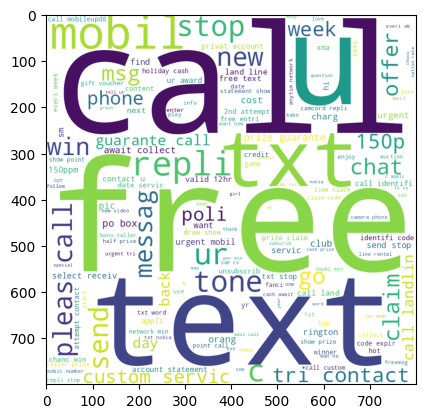

In [33]:
import matplotlib.pyplot as plt
spam_wc = wc.generate(df[df['lable']==1]['transformed_text'].str.cat(sep=" "))
plt.imshow(spam_wc)

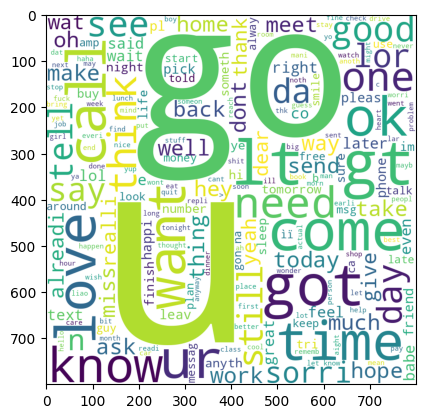

In [44]:
ham_wc = wc.generate(df[df['lable']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(ham_wc)

In [45]:
spam_msgs = []
for msg in df[df['lable']==1]['transformed_text'].tolist():
    # print(msg)
    for word in msg.split():
        spam_msgs.append(word)


In [42]:
spam_msgs
len(spam_msgs)

9939

<Axes: ylabel='0'>

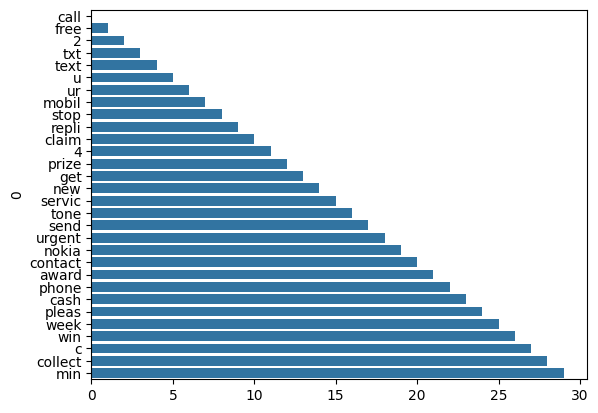

In [46]:
from collections import Counter
import seaborn as sns # Import seaborn library

Counter(spam_msgs)                   # It count the most accuring workds in the list
Counter(spam_msgs).most_common(30)   # It return most common 30 words which are used
pd.DataFrame(Counter(spam_msgs).most_common(30)) # COnvert into data frame

# making barplot of this most cooman wors
sns.barplot(pd.DataFrame(Counter(spam_msgs).most_common(30))[0])

In [47]:
ham_msgs = []
for msg in df[df['lable']==0]['transformed_text'].tolist():
    for word in msg.split():
        ham_msgs.append(word)


In [48]:
ham_msgs
len(ham_msgs)

35404

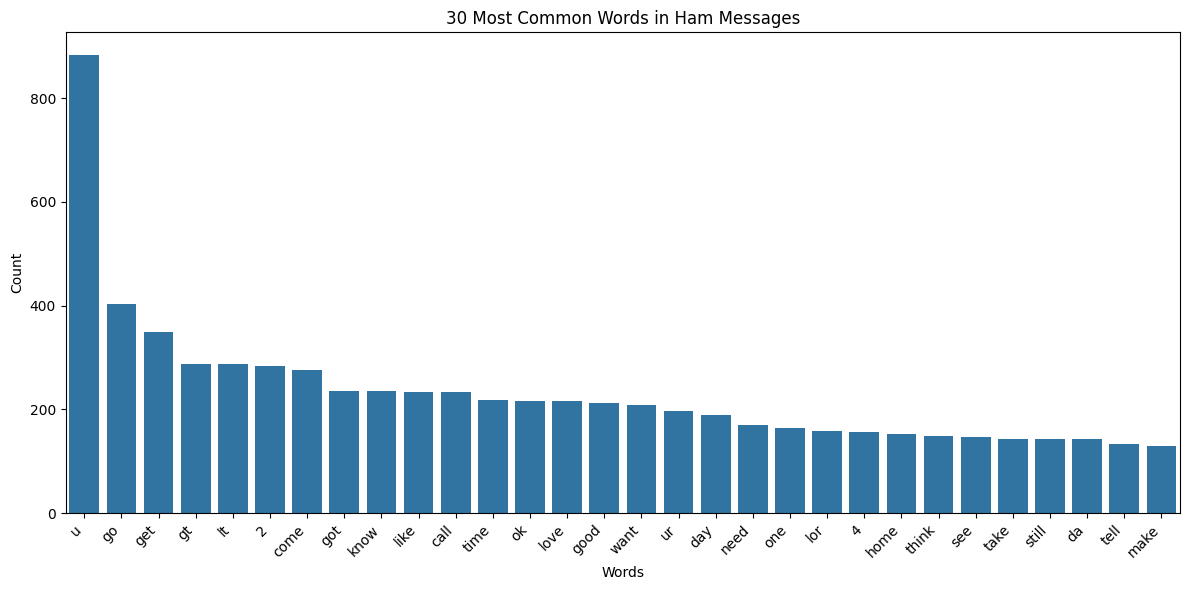

In [49]:
from collections import Counter
import seaborn as sns
import matplotlib.pyplot as plt

# Get the 30 most common words in ham messages
ham_common_words = Counter(ham_msgs).most_common(30)

# Convert to DataFrame for plotting
ham_common_words_df = pd.DataFrame(ham_common_words, columns=['Word', 'Count'])

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Word', y='Count', data=ham_common_words_df)
plt.title('30 Most Common Words in Ham Messages')
plt.xlabel('Words')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [62]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)


In [63]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['lable'].values


In [64]:
print("Shape of X (features):", X.shape)
print("Shape of y (labels):", y.shape)


Shape of X (features): (5169, 3000)
Shape of y (labels): (5169,)


In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [95]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [96]:
bnb = BernoulliNB()

In [99]:
# Bernoulli Naive Bayes
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print("Accuracy => ",accuracy_score(y_test,y_pred3))
print("Confussion Metrix => ",confusion_matrix(y_test,y_pred3))
print("Precision Score => ",precision_score(y_test,y_pred3))

Accuracy =>  0.9835589941972921
Confussion Metrix =>  [[895   1]
 [ 16 122]]
Precision Score =>  0.991869918699187


In [77]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9758220502901354, 0.9747899159663865)